# Notebook 2: SpatioTemporal EDA
The Goal: Visualize the Gold Layer feature engineering. Show the interaction between physical space and cultural timelines.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

sns.set_theme(style="whitegrid")
abt = pd.read_parquet('../data/gold/model_input.parquet')
coords = pd.read_parquet('../data/silver/outlet_coordinates_clean.parquet')


### Plot 1: The Catchment Heatmap

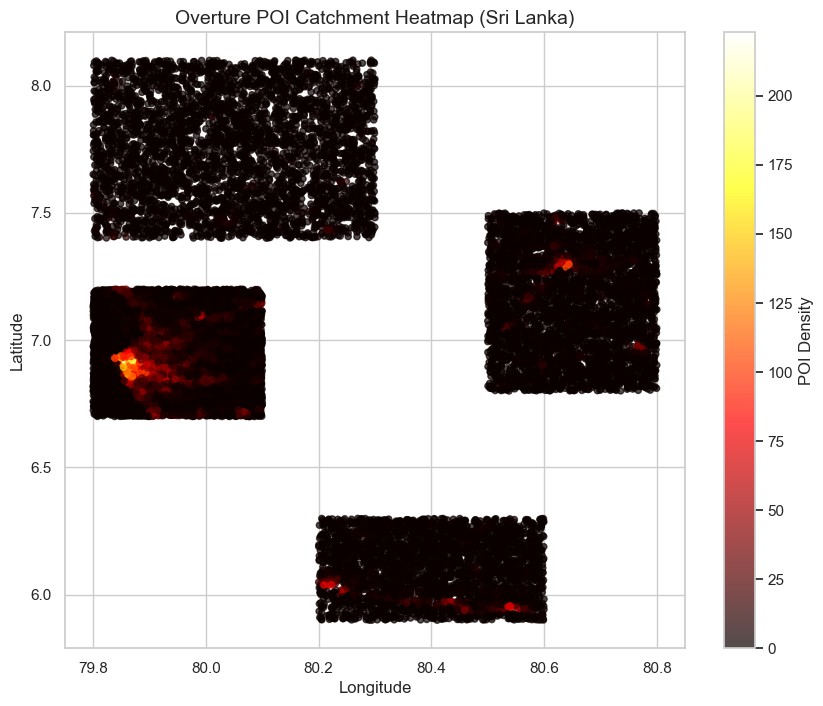

In [2]:
plt.figure(figsize=(10, 8))
sample_coords = coords.merge(abt[['Outlet_ID', 'poi_total_catchment']].drop_duplicates(), on='Outlet_ID')

scatter = plt.scatter(sample_coords['Longitude'], sample_coords['Latitude'], 
            c=sample_coords['poi_total_catchment'], cmap='hot', alpha=0.7, s=20)
plt.colorbar(scatter, label='POI Density')
plt.title("Overture POI Catchment Heatmap (Sri Lanka)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


### Plot 2: The Timeline Interaction (The 'Big Match' Spike)

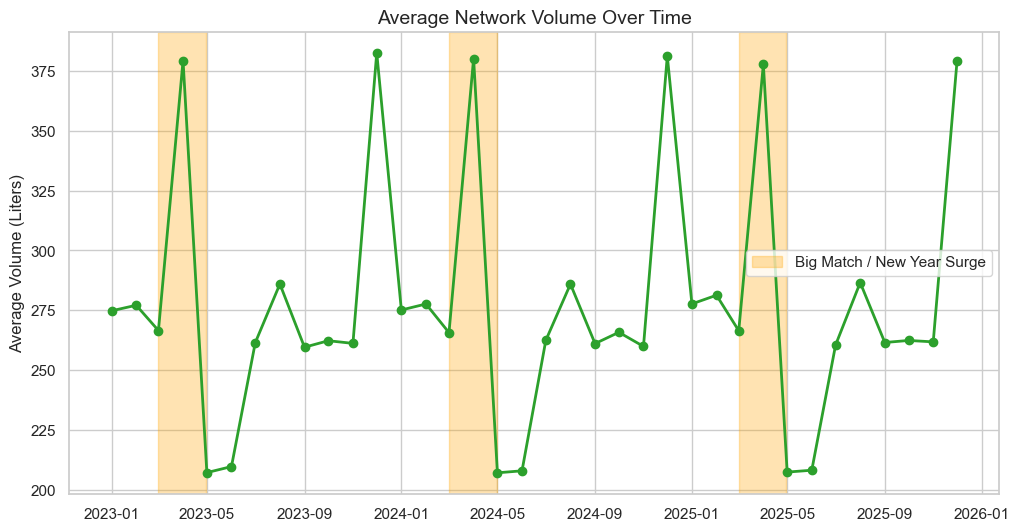

In [3]:
time_series = abt.groupby(['Year', 'Month'])['Total_Volume'].mean().reset_index()
time_series['Date'] = pd.to_datetime(time_series[['Year', 'Month']].assign(DAY=1))

plt.figure(figsize=(12, 6))
plt.plot(time_series['Date'], time_series['Total_Volume'], marker='o', linestyle='-', linewidth=2, color='#2ca02c')

# Highlight March/April (Big Match Season)
for year in [2023, 2024, 2025]:
    plt.axvspan(pd.Timestamp(f"{year}-03-01"), pd.Timestamp(f"{year}-04-30"), color='orange', alpha=0.3, label='Big Match / New Year Surge' if year==2023 else "")

plt.title("Average Network Volume Over Time", fontsize=14)
plt.ylabel("Average Volume (Liters)")
plt.legend()
plt.show()
